# Analisi OLS dataset Auto
In questo assignment utilizzerò la libreria statsmodels e i suoi importanti strumenti per operare una regressione lineare, ricavarne i dati degni di nota e rimuovere gli esempi  considerati influenti secondo la soglia di Cook, in modo da migliorare il modello. Il dataset oggetto di questo studio, Auto.csv, si compone di 398 esempi, in questo caso automobili, e 9 variabili.

## 1) Processi preliminari

In [ ]:
# Prima di tutto importiamo le librerie necessarie quali "pandas" per la manipolazione del dataframe, "statmodels" per la creazione del modello di regressione lineare,
# nonché per per l'impiego di tools come il variance inflation factor (VIF) e gli influence plot.
# Matplotlib e seaborn fondamentali per la visualizzazione delle rlazioni tra esempi e variabili e numpy per il calcolo dei vettori e matrici.

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import influence_plot
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Apriamo il dataframe e visualizziamo le variabili e il numero di esempi, rispettivamente 9 e 397
# I regressori che utilizzeremo nella nostra analisi saranno: cylinders, il quale indica il numero di cilindri nel motore; displacement, ovvero il volume dei cilindri in pollice cubi;
# Horsepower, la potenza del motore in cavalli; weight il peso della macchina in libbre; accelaration, il tempo che impiega per andare da 0 a 60 migle all'ora (mph);
# Year, l'anno di produzione del modello e origin, l'origine geografica indicata categoricamente con i numeri 1.USA 2.Europa e 3.Giappone.
# La variabile responso sarà mpg, indicanti le miglie per gallone.

df = pd.read_csv("Auto.csv")
df.shape
df.head(20)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [ ]:
# Non risultano valori nulli all'interno del dataframe.
print("Numero di valori nulli:", df.isnull().sum())


Numero di valori nulli: mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


In [ ]:
# Transformiamo la variabile categorica origin in due colonne numeriche: Origin_Europa e Origin_Giappone.
# Rendiamo i valori del regressore horsepower numerici (float64).

mappa = {1: "USA", 2: "Europa", 3: "Giappone"}
df["origin"] = df["origin"].map(mappa)
df["origin"] = pd.Categorical(df["origin"],
                             categories=["USA", "Europa", "Giappone"],
                             ordered=True)

df = pd.get_dummies(df, columns=["origin"], prefix="origin", drop_first=True, dtype=np.float64)


df["horsepower"] = df["horsepower"].replace("?", np.nan)
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())
df["horsepower"] = df["horsepower"].astype(np.float64)

print(df.columns)






Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'name', 'origin_Europa', 'origin_Giappone'],
      dtype='object')


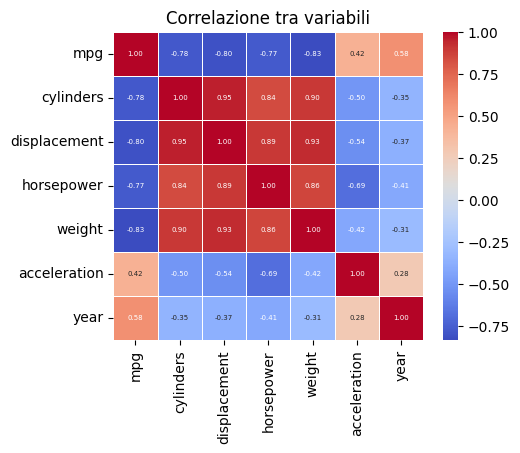

In [ ]:
# Osserviamo le varie correlazioni tra le variabili visualizzate tramite heatmap di Seaborn.
# Notiamo una fortissima correlazione tra displacement, cylinders, horsepower e weight il valore minimo e 0.93.
# Allo stesso modo la variabile responso mpg dimostra una discreta relazione negativa con cylinders, displacement, horsepower e weight,
# Con un indice minimo di -0.77 (horsepower) e un massimo di -0.83 (weight), il che ha senso visto che il peso ha impatto negativo sul consumo del carburante,
# e di conseguenza sulla distanza che la vettura può percorrere.

subset = df[["mpg", "cylinders","displacement", "horsepower", "weight", "acceleration", "year"]]

correlation = subset.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,annot_kws={"size": 5})
plt.title("Correlazione tra variabili")
plt.show()


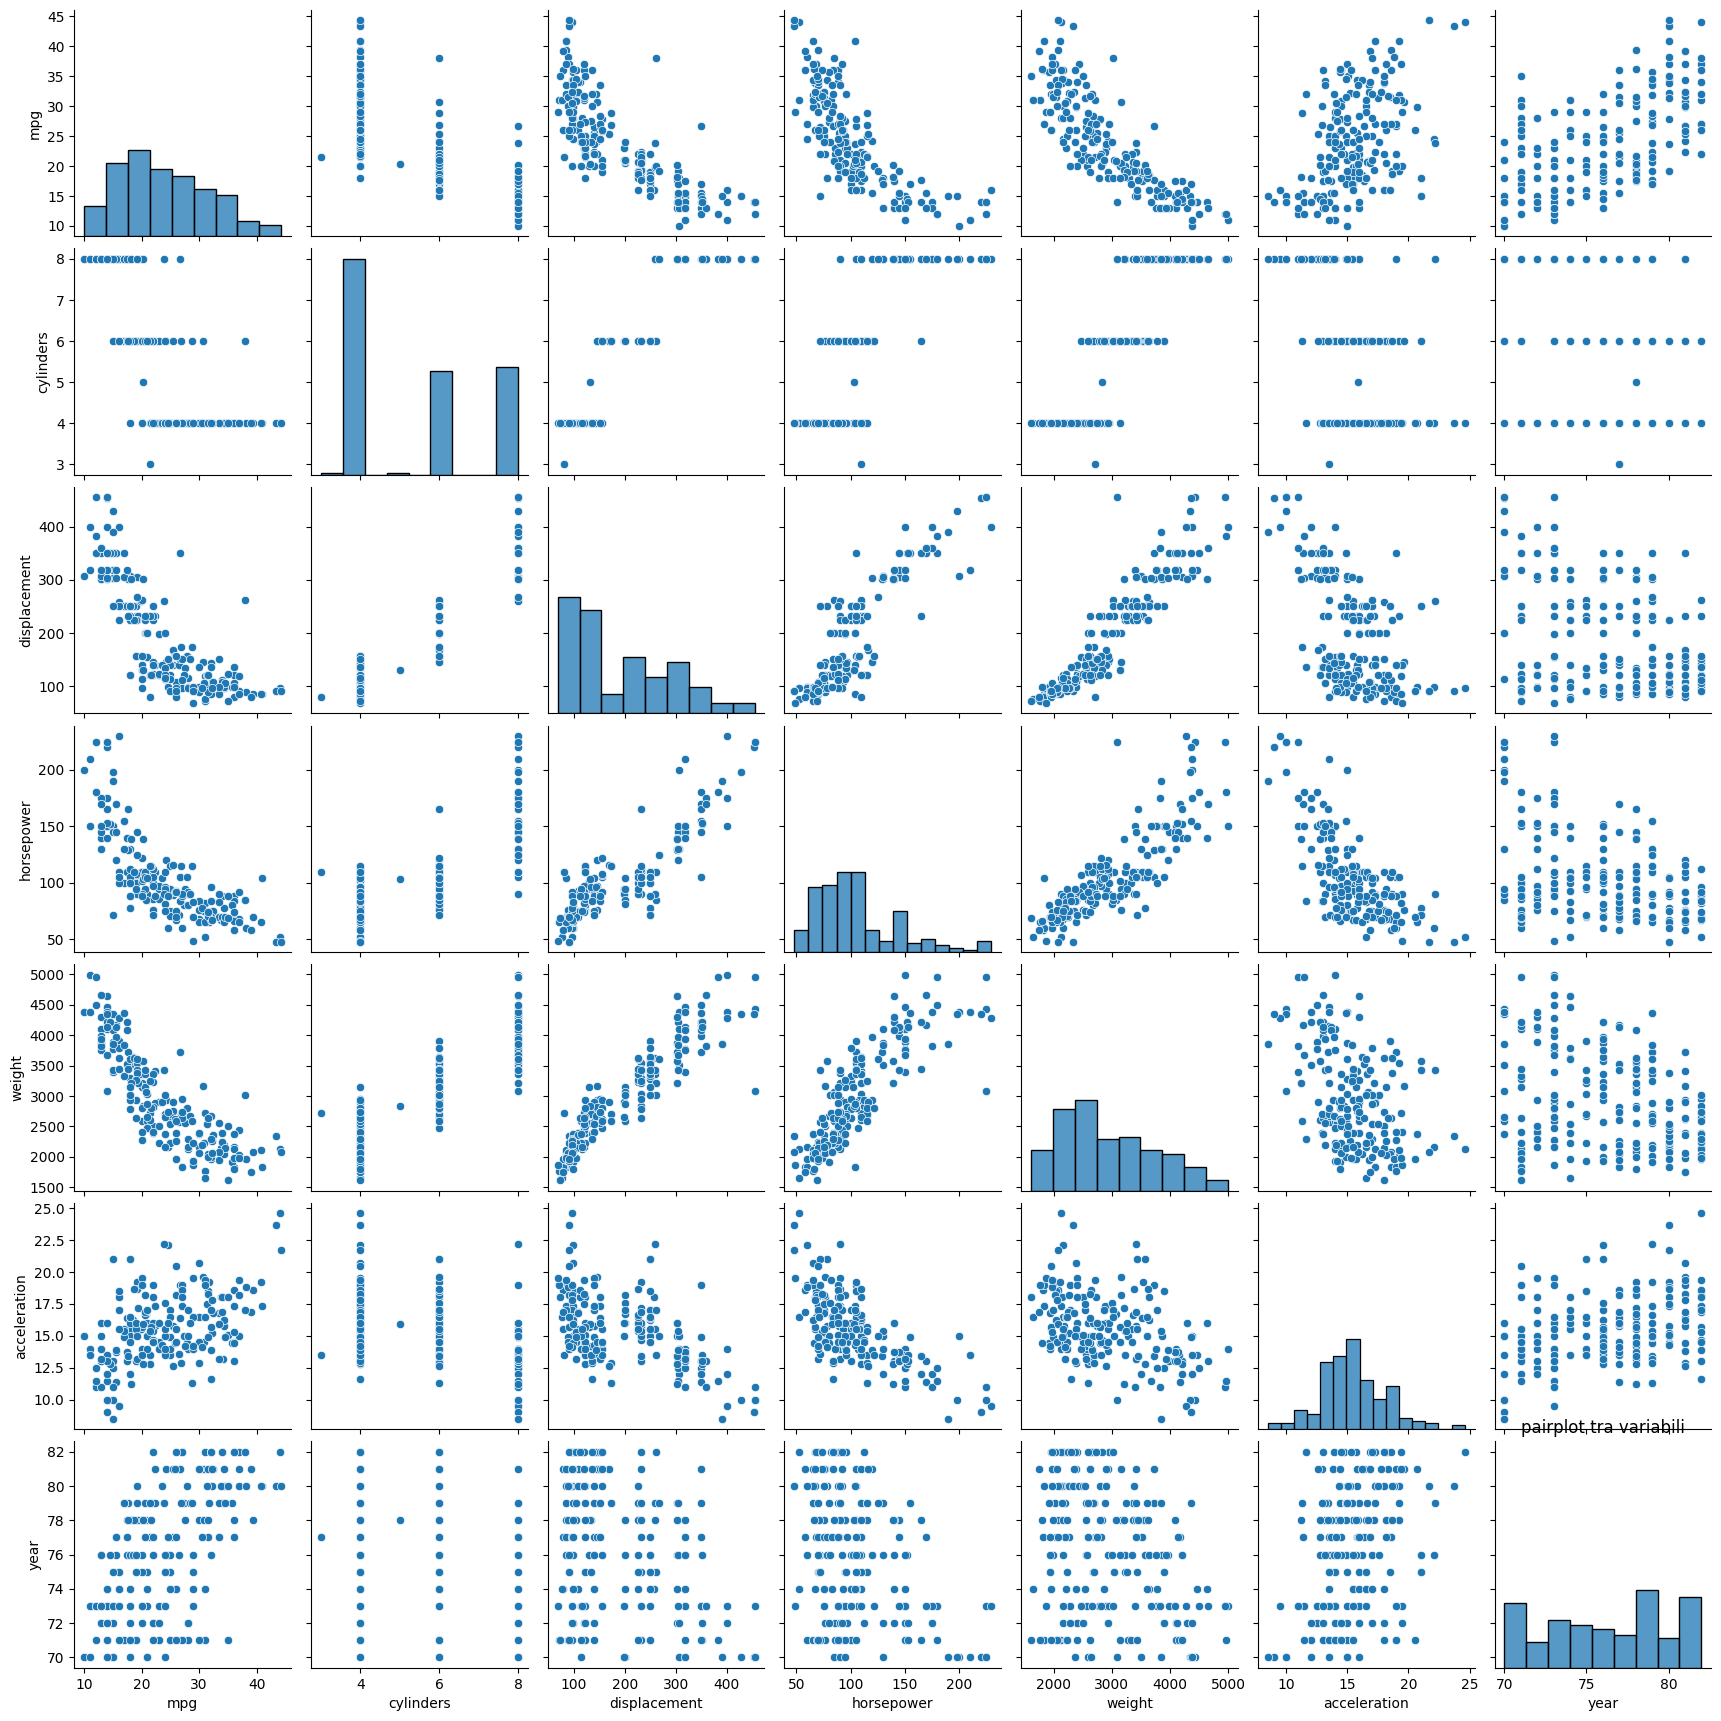

In [ ]:
# I plot confermano queste relazioni attraverso una riconoscibile linearità.

sns.pairplot(df[['mpg', 'cylinders', 'displacement', "horsepower", 'weight', 'acceleration', 'year']].sample(200))
plt.title("pairplot tra variabili")
plt.show()

In [ ]:
# Rimuoviamo la colonna "name"

df_clean= df.drop(["name"], axis=1)
df_clean.head(20)



,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin_Europa,origin_Giappone
0,18.0,8,307.0,130.0,3504,12.0,70,0.0,0.0
1,15.0,8,350.0,165.0,3693,11.5,70,0.0,0.0
2,18.0,8,318.0,150.0,3436,11.0,70,0.0,0.0
3,16.0,8,304.0,150.0,3433,12.0,70,0.0,0.0
4,17.0,8,302.0,140.0,3449,10.5,70,0.0,0.0
5,15.0,8,429.0,198.0,4341,10.0,70,0.0,0.0
6,14.0,8,454.0,220.0,4354,9.0,70,0.0,0.0
7,14.0,8,440.0,215.0,4312,8.5,70,0.0,0.0
8,14.0,8,455.0,225.0,4425,10.0,70,0.0,0.0
9,15.0,8,390.0,190.0,3850,8.5,70,0.0,0.0


## 2) Regressione lineare ed analisi

In [ ]:
# Per la regressione lineare utilizziamo il metodo smf.ols che mi ricava automaticamente l'intercetta e converte le variabili categoriche in dummies
# Quest'ultimo processo è gia stato eseguito precendentemente.
# Il modello presenta un buon valore sia nell' R squared che nell' Adjusted R squared, 0.82
# F statistic e il suo P value rigettano l'ipotesi nulla e ci indica un modello fortemente significativo.
# Le variabili horsepower e acceleration presentano valori relativante superiori per quanto riguarda I P value in T, il ché li rende meno significativi per il modello.

model = smf.ols("mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin_Europa + origin_Giappone", data=df_clean)
regr = model.fit()
summary = regr.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     228.8
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          9.00e-142
Time:                        17:49:17   Log-Likelihood:                -1033.5
No. Observations:                 397   AIC:                             2085.
Df Residuals:                     388   BIC:                             2121.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -19.4733      4.611     

Text(0.5, 1.0, 'Histogram of residuals')

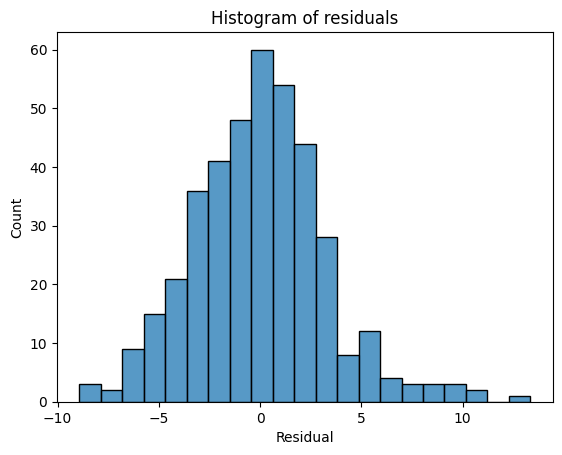

In [ ]:
# Elaboriamo l'istogramma dei residui, la loro distribuzione è pseudo-gaussiana, confermato dagli infimi valori della Skew, 0.409, e della JB probability.

model_fitted_y = regr.fittedvalues
resid = regr.resid
fig = sns.histplot(data = resid)
fig.set_xlabel('Residual')
fig.set_title('Histogram of residuals')



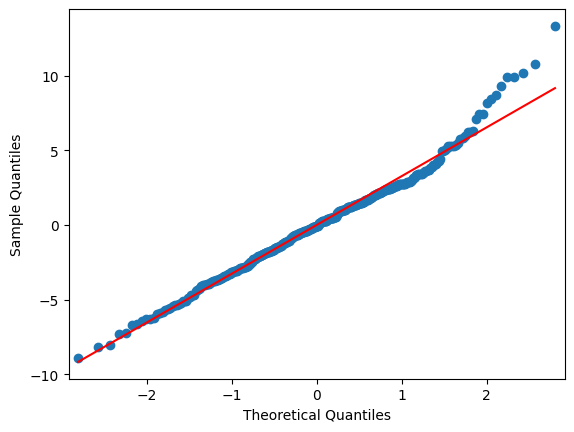

In [ ]:
# Ciò è reiterato dal Q-Q plot nel quale i residui seguono la distribuzione normale eccetto per la coda in alto a destra.

fig=sm.qqplot(data = resid, line = 's')
plt.show()

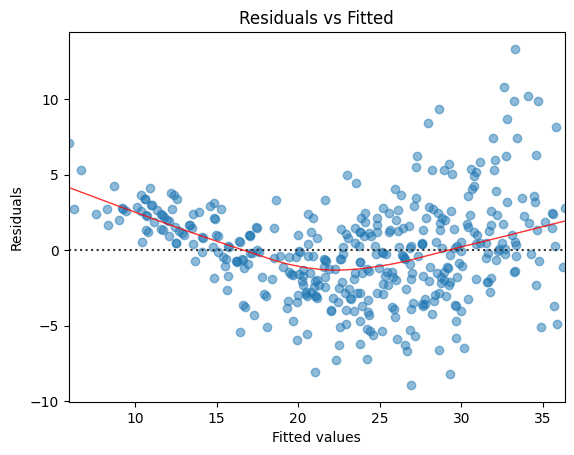

In [ ]:
# I punti seguono la LOWESS strettamente, con l'aumentare dei valori fittati aumenta la varianza.
# Di fatto i residui non mostrano omoschedasticità.

plot = sns.residplot(x=model_fitted_y, y='mpg', data= df_clean, lowess=True,
                     scatter_kws={'alpha': 0.5},line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plot.set_title('Residuals vs Fitted')
plot.set_xlabel('Fitted values')
plot.set_ylabel('Residuals');
plt.show()

In [ ]:
# I plot mostrano la distribuzione dei dati a seconda delle variabili considerate, si notano la presenza di outliers nel parametri mpg, displacement e acceleration.
# Quest'ultimo presenta in generale una distribuzione normale, maggiormente simmetrica rispetto agli altri.

def num_plot(df_clean, cat_length = 10, remove = ["name"], hist_bins = 10, figsize = (17,4)):

    num_col = [col for col in df.columns if df[col].dtypes != "O"
                and len(df[col].unique()) >= cat_length]

    if len(remove) > 0:
        num_col = [x for x in num_col if (x not in remove)]

    for i in num_col:
        fig, axes = plt.subplots(1, 3, figsize = figsize)
        df.hist(str(i), bins = hist_bins, ax=axes[0])
        df.boxplot(str(i),  ax=axes[1], vert=False);
        try:
            sns.kdeplot(np.array(df[str(i)]))
        except: ValueError

        axes[1].set_yticklabels([])
        axes[1].set_yticks([])
        axes[0].set_title(i + " | Histogram")
        axes[1].set_title(i + " | Boxplot")
        axes[2].set_title(i + " | Density")
        plt.show()

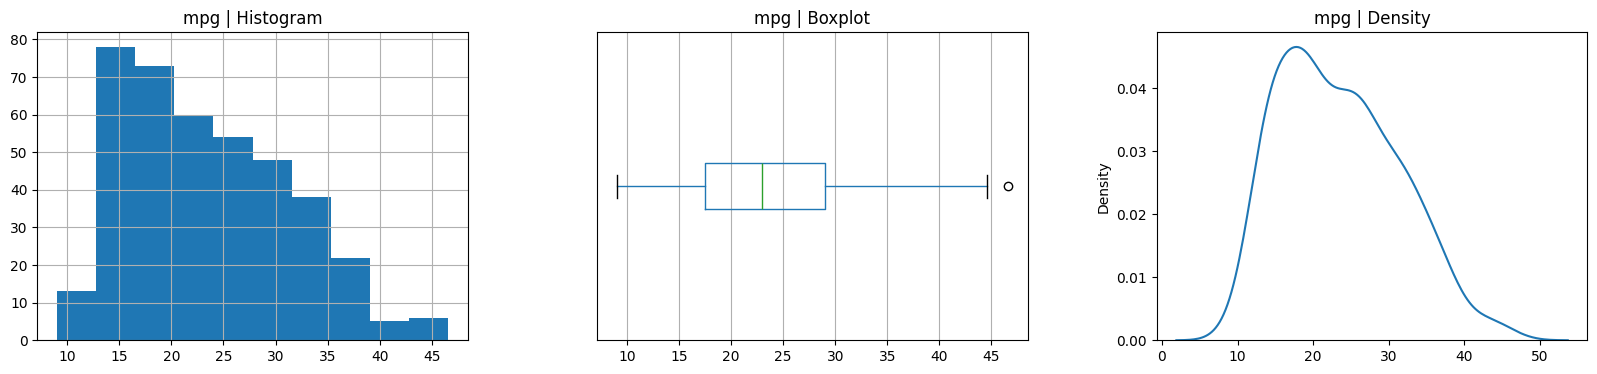

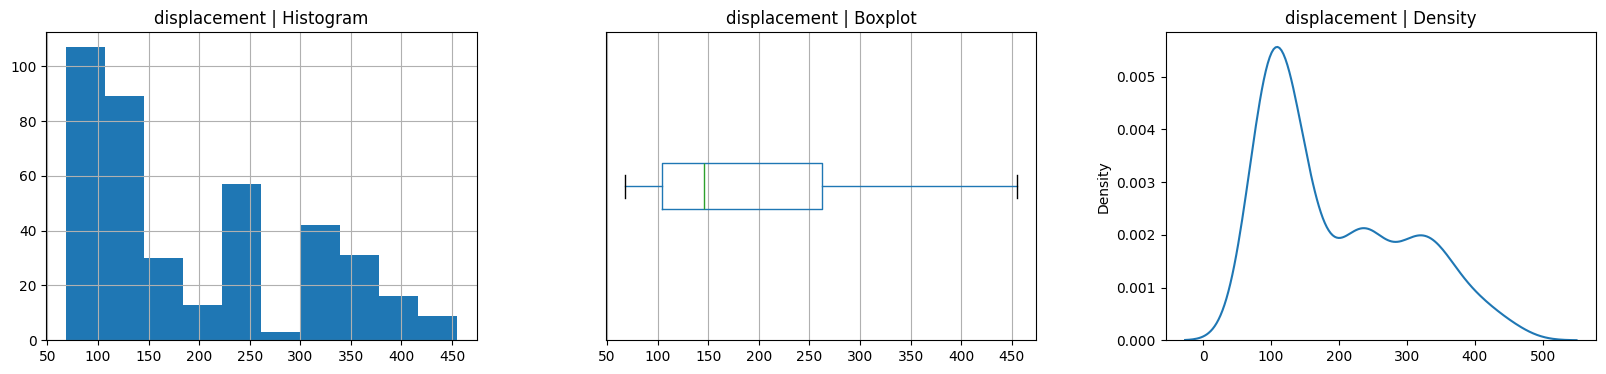

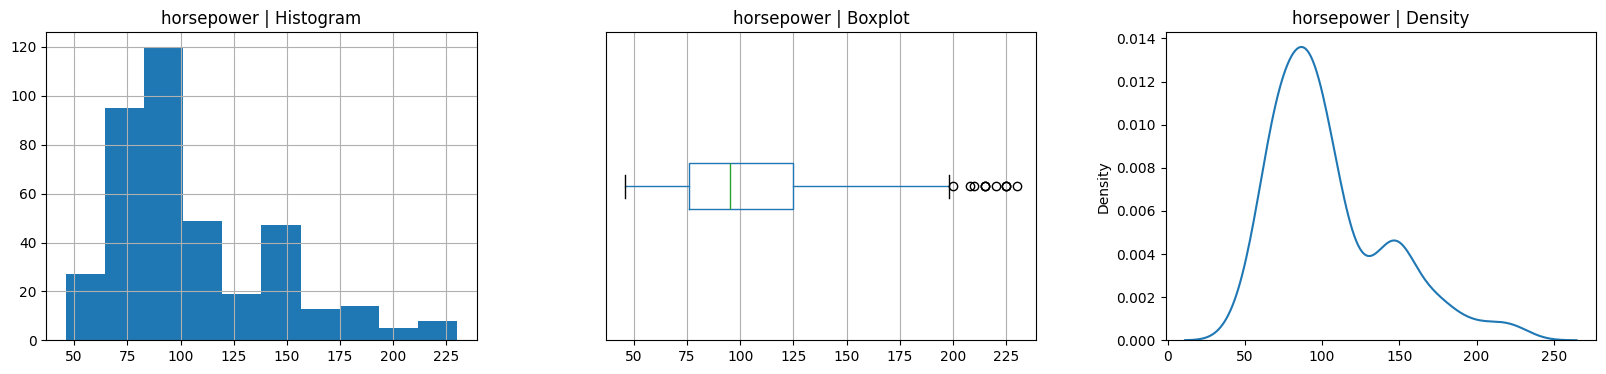

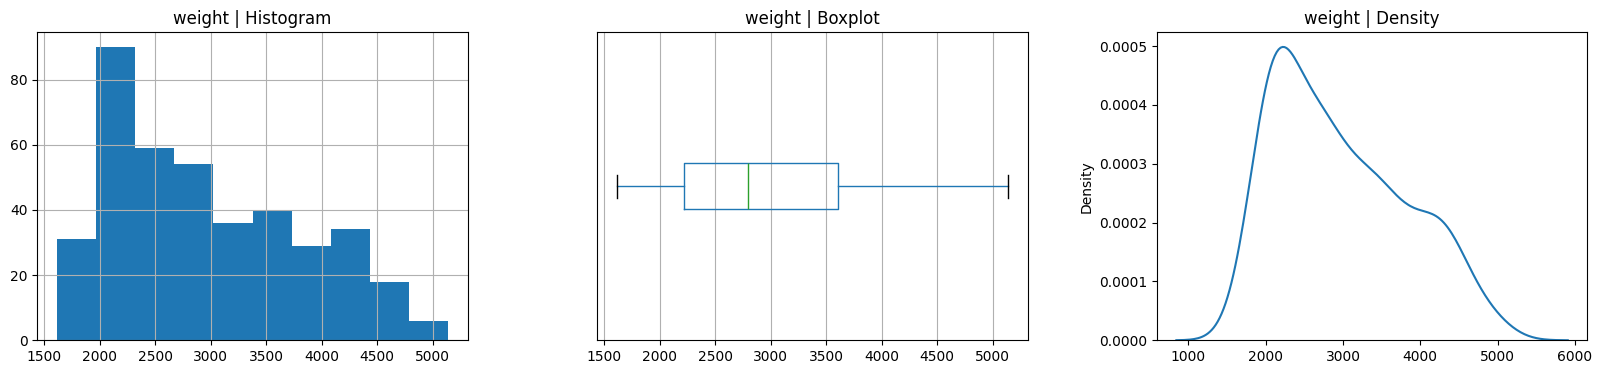

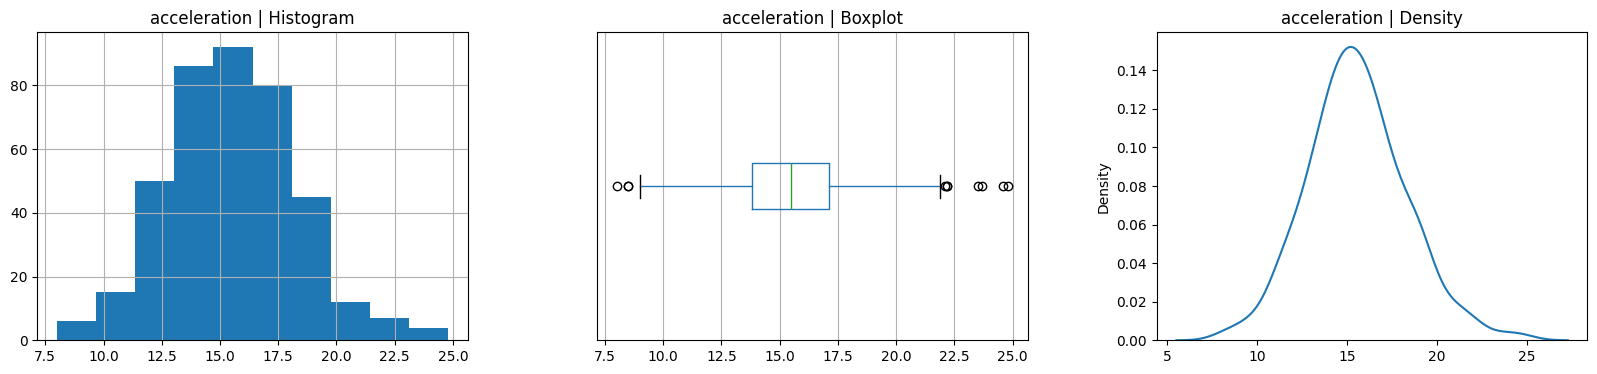

In [ ]:
num_plot(df_clean, cat_length = 16, hist_bins = 10, figsize = (20,4))

## 3) Feature selection tramite VIF

In [ ]:
# Calcoliamo i VIF  delle singole variabili. Notevole è il valore associato a displacement 22.9, il più alto, seguono weight e cylinders (10.7)

X = df_clean.drop(columns=['mpg'])
# Si aggiunge l'intercetta (intercept)
X = add_constant(X)
# Calcolo del VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

           Feature         VIF
0            const  771.905309
1        cylinders   10.723435
2     displacement   22.907162
3       horsepower    9.178397
4           weight   10.708780
5     acceleration    2.526237
6             year    1.286517
7    origin_Europa    1.638765
8  origin_Giappone    1.725432


In [ ]:
# Applichiamo nuovamente la regressione lineare senza i regressori che presentavano un valore di VIF pari e maggiore di 10.
# C'é un abbassamento della spiegabilità del modello, R squared e Adjusted al 75%. Questi due parametri sono molto vicini, ciò rifiuta fortunatamente l'ipotesi di overfitting legato ai regressori scelti.
# Il modello tramite la F statistic si mostra fortemente significativo con un'indice minore di 0.05, così come tutte le restanti variabili.
# Il modello presenta ancora multicollinearità, probabilmente insito nei dati.
# Sia P Omnibus che P(JB) ci indicano un distacco dalla normalità, con il loro valore prossimo allo zero.
# La kurtosis riscontra un'avvicinamento rispetto al valore normale di 3. Segno che la distribuzione è simile ad una gaussiana, ma continua ad essere asimmetrica.

model_m = smf.ols("mpg ~  acceleration + horsepower + year + origin_Europa + origin_Giappone", data=df_clean)
regress = model_m.fit()
summary = regress.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     238.0
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          3.19e-116
Time:                        17:49:20   Log-Likelihood:                -1102.3
No. Observations:                 397   AIC:                             2217.
Df Residuals:                     391   BIC:                             2240.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -10.8421      5.283     

Text(0.5, 1.0, 'Histogram of residuals')

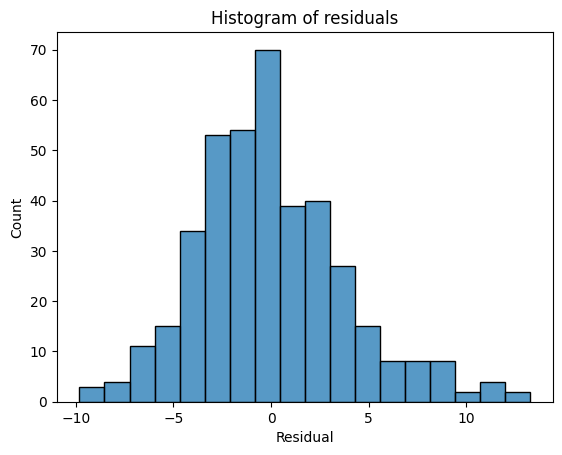

In [ ]:
model_fitted_x = regress.fittedvalues
resid = regress.resid
fig = sns.histplot(data = resid)
fig.set_xlabel('Residual')
fig.set_title('Histogram of residuals')



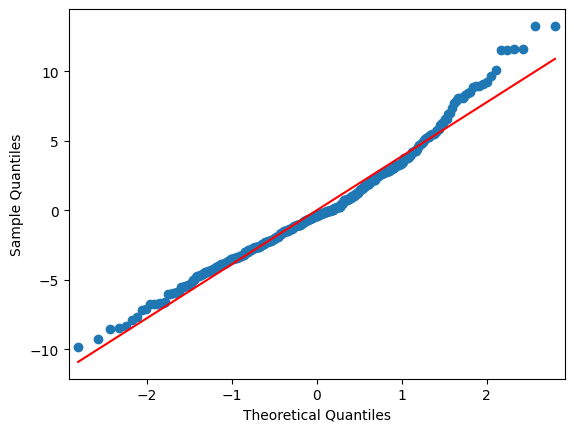

In [ ]:
fig1 =sm.qqplot(data = resid, line = 's')
plt.show()


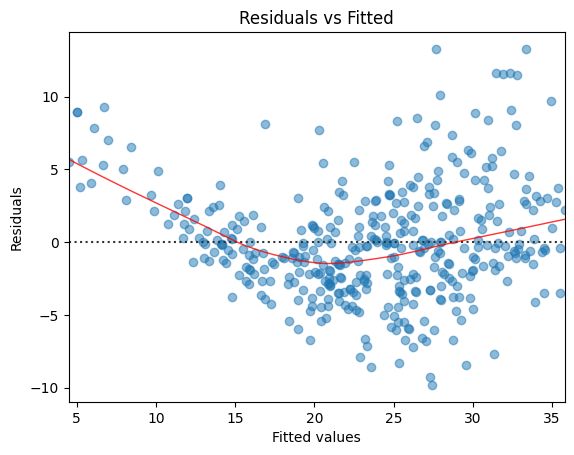

In [ ]:
# Benché ci sia un progresso in positivo, la distribuzione dei punti, a ventaglio, indica che i residui non sono ancora omoschedastici.

plot = sns.residplot(x=model_fitted_x, y='mpg', data=df_clean, lowess=True,
                     scatter_kws={'alpha': 0.5},line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plot.set_title('Residuals vs Fitted')
plot.set_xlabel('Fitted values')
plot.set_ylabel('Residuals');
plt.show()

## 4) Individuazione ed eliminazione dei punti influenti

In [ ]:
# Chiamiamo la funzione "get_influence" per ottenere i livelli di influenza dei singoli esempi del dataframe.
# L'esempio numero 393 dimostra di essere influente sulla stima di quasi tutti i coefficienti con valori df beta maggiori della soglia, 0.1.
# Sia lo Student Residual che lo Standard Residual confermano questo aspetto con un valore lievemente maggiore di 2.
# Anche le distanze di Cook e DIFFTS superano la soglia di 0.01, a conferma del peso sul modello.

influence = regr.get_influence()
influence.summary_frame()

,dfb_Intercept,dfb_cylinders,dfb_displacement,dfb_horsepower,dfb_weight,dfb_acceleration,dfb_year,dfb_origin_Europa,dfb_origin_Giappone,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,0.076886,0.072661,-0.013133,-0.056608,-0.013349,-0.055897,-0.068485,-0.006430,-0.006065,0.002396,0.958471,0.022937,0.146852,0.958370,0.146837
1,0.010025,0.005893,0.007846,0.007887,-0.019526,0.001710,-0.010816,0.000814,-0.000806,0.000152,0.273453,0.017913,0.036931,0.273127,0.036887
2,0.047155,0.057423,-0.007341,0.001744,-0.048978,-0.025450,-0.043429,-0.007531,-0.014171,0.001706,0.838415,0.021380,0.123925,0.838094,0.123878
3,0.012093,0.026018,-0.010814,0.008383,-0.016746,-0.001286,-0.015235,-0.005786,-0.007535,0.000205,0.286771,0.021930,0.042941,0.286431,0.042890
4,0.052160,0.057769,-0.024640,-0.024691,-0.010956,-0.049292,-0.043424,-0.010327,-0.013019,0.001278,0.659498,0.025772,0.107264,0.659017,0.107186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,0.009692,0.019624,0.001741,0.002772,-0.015215,0.013144,-0.021273,0.017301,0.019608,0.000245,-0.329396,0.019879,-0.046911,-0.329017,-0.046857
393,-0.376099,0.015835,0.202021,0.183795,-0.306764,0.494159,0.255136,0.297734,0.041016,0.047848,2.552198,0.062012,0.656226,2.570576,0.660952
394,0.001515,-0.014552,0.004147,-0.013581,0.003383,-0.037676,0.022500,-0.014736,-0.022310,0.000374,0.313409,0.033123,0.058009,0.313044,0.057941
395,0.022730,0.009262,0.007162,-0.015463,-0.002017,-0.014543,-0.023858,0.022299,0.024772,0.000271,-0.360036,0.018477,-0.049398,-0.359632,-0.049343


In [ ]:
leverage = influence.hat_matrix_diag

standardized_residuals = influence.resid_studentized_internal

studentized_residuals = influence.resid_studentized_external

cooks = influence.cooks_distance

dffits = influence.dffits

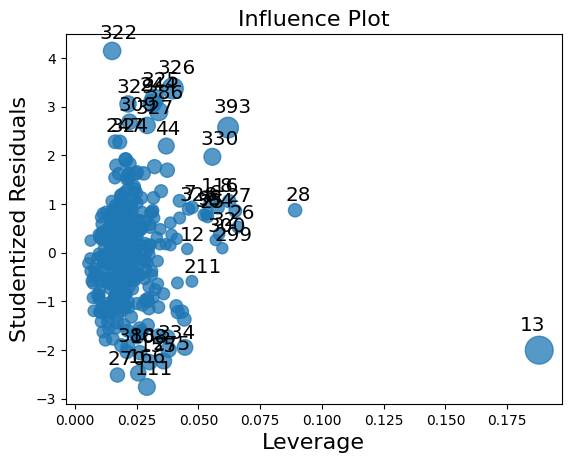

In [ ]:
#I grafici reiterano l'analisi della tabella sono identificabili un gruppo di esempi relativamente influenti che presentano un valore del coefficente studentizzato maggiore di 2
# Il gruppo spazia in un intervallo che va da 2.5 a 3.5, l'esempio 393 trattato precedentemente è in questo contesto. Degno di nota è l'outlier 322 che supera la soglia dei 4.
# L'esempio 13 mostra un'alto indice di leverage rispetto ai restanti records.

influence_plot(regr,criterion='Cooks',size=20, fontdict={"size": 5})
plt.show()

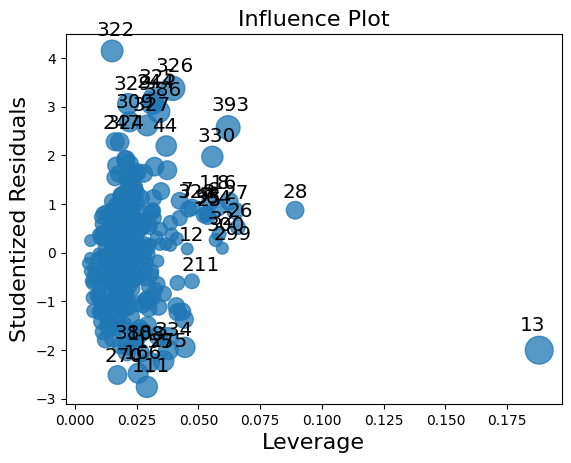

In [ ]:
# Si giunge allo stesso risultato con il criterio DFFITS.

influence_plot(regr,criterion='DFFITS', size=20, fontdict={"size": 5})
plt.show()

In [ ]:
# Formuliamo e grafichiamo le threshold di Cook, della media delle distanze, 4/n...

mean_cooks = np.mean(cooks[0])
mean_cooks
th_mean = [3*mean_cooks for i in df_clean.index]
n=df_clean.shape[0]
th_n = [4/n for i in df_clean.index]

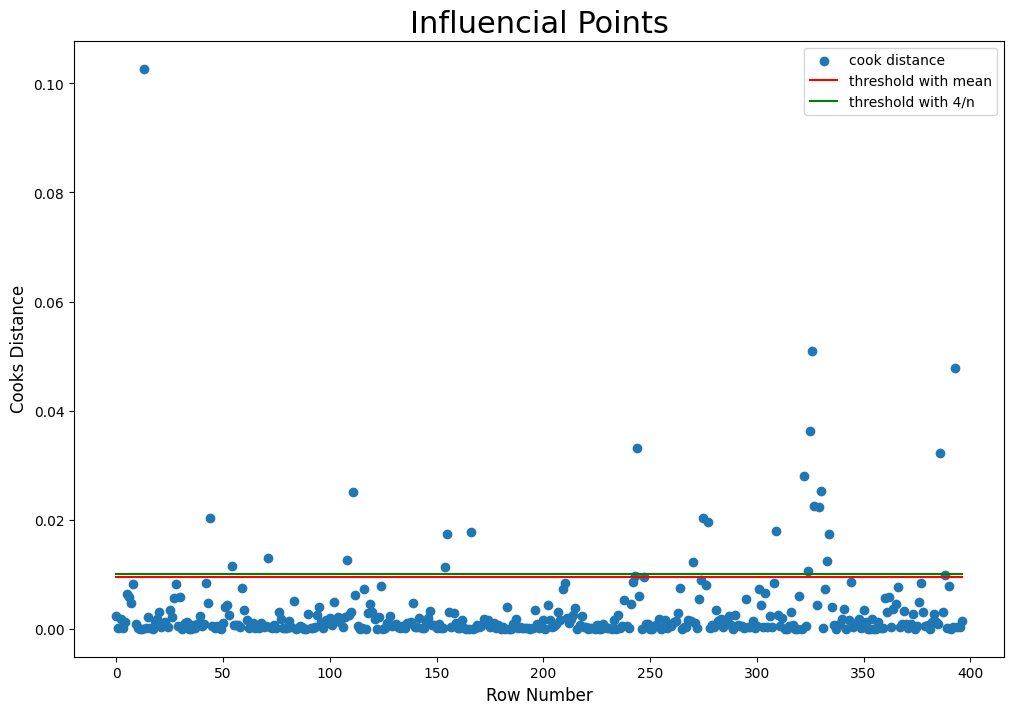

In [ ]:
plt.figure(figsize = (12, 8))
plt.scatter(df_clean.index, cooks[0])
plt.plot(df_clean.index, th_mean, color="red")
plt.plot(df_clean.index, th_n, color="green")
plt.legend(['cook distance','threshold with mean','threshold with 4/n'], loc ="upper right")
plt.xlabel('Row Number', fontsize = 12)
plt.ylabel('Cooks Distance', fontsize = 12)
plt.title('Influencial Points', fontsize = 22)
plt.show()

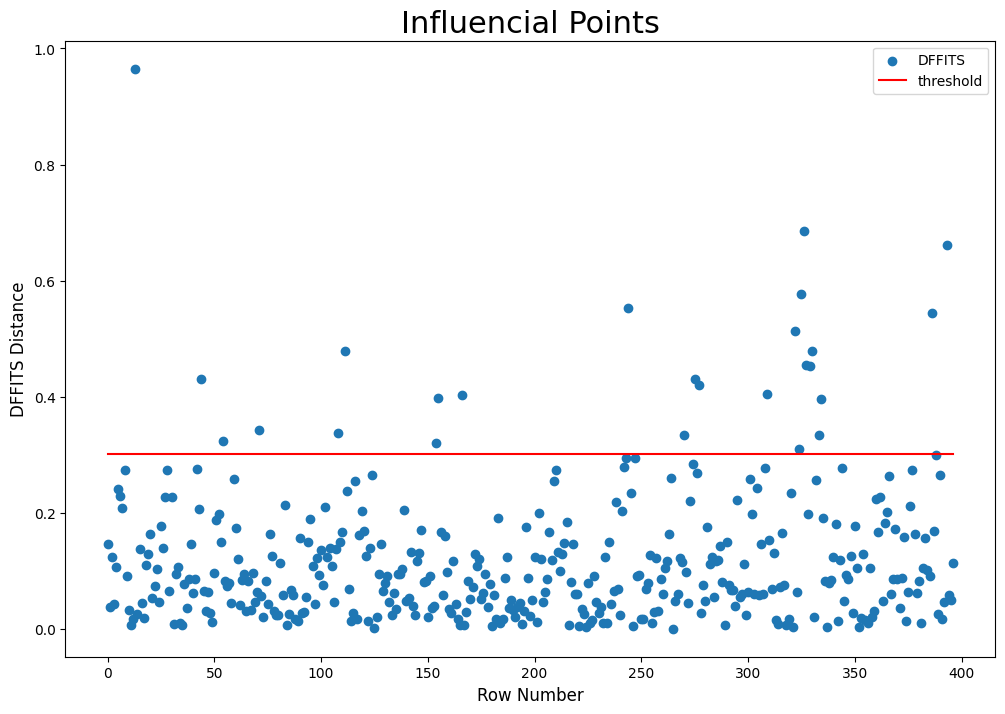

In [ ]:
#... e DFITTS.

th_dffits = [dffits[1] for i in df_clean.index]
plt.figure(figsize = (12, 8))
plt.scatter(df_clean.index, abs(dffits[0]))
plt.plot(df_clean.index, th_dffits, color="red")
plt.legend(['DFFITS','threshold'], loc ="upper right")
plt.xlabel('Row Number', fontsize = 12)
plt.ylabel('DFFITS Distance', fontsize = 12)
plt.title('Influencial Points', fontsize = 22)
plt.show()

In [ ]:
# Eliminiamo i punti considerat influenti secondo il criterio di Cook.

df_clean_cook = df_clean[cooks[0] <= th_mean]
df_clean_cook.shape

(369, 9)

In [ ]:
# Eseguimao la regressione lineare sul dataframe modificato.
# C'è un sensibile miglioramento dell' R quadro e dell'Adjusted 80%.
# L'Omnibus ,0-005, lo Skew, 0.2 e la Kurtosis, 3, segnalano un miglioramento nella distribuzione dei residui.
# Si nota un'aumento della multicollinearità, la Condition Number passa dai 3590 della regressione precedente, ai 3660 attuali.
# Al contempo, i valori di AiC e BIC sono decisamente migliori, 1910 e 1933, a fronte dei rispettivi 2217 e 2240.

model_cook = smf.ols("mpg ~   horsepower + acceleration + year + origin_Europa + origin_Giappone", data=df_clean_cook)
regr_cook = model_cook.fit()
summary_cook = regr_cook.summary()
print(summary_cook)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     303.8
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          2.58e-127
Time:                        17:49:23   Log-Likelihood:                -948.87
No. Observations:                 369   AIC:                             1910.
Df Residuals:                     363   BIC:                             1933.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.2750      4.536     

Text(0.5, 1.0, 'Histogram of Residuals')

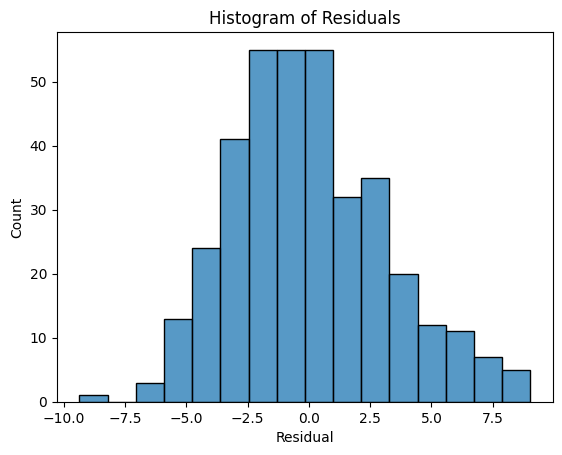

In [ ]:
# Come già visto nei parametri della regressione, i residui seguono una distribuzione approssimativamente normale con un'accento sul lato positivo.

model_fitted_cook_r_y = regr_cook.fittedvalues
resid_cook_r = regr_cook.resid

fig = sns.histplot(data = resid_cook_r)
fig.set_xlabel('Residual')
fig.set_title('Histogram of Residuals')

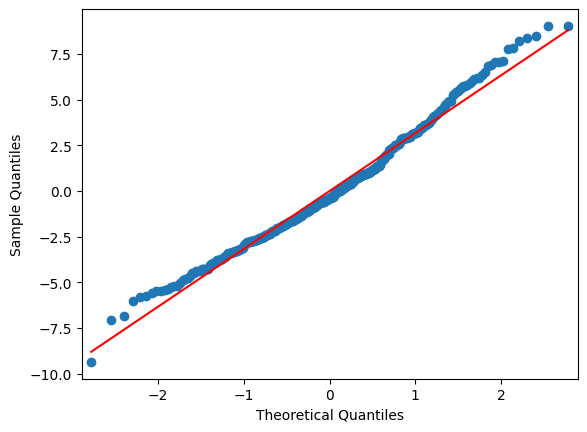

In [ ]:
# Ciò è ravvisabile anche nel Q-Q plot.

fig1 =sm.qqplot(data = resid_cook_r, line = 's')
plt.show()

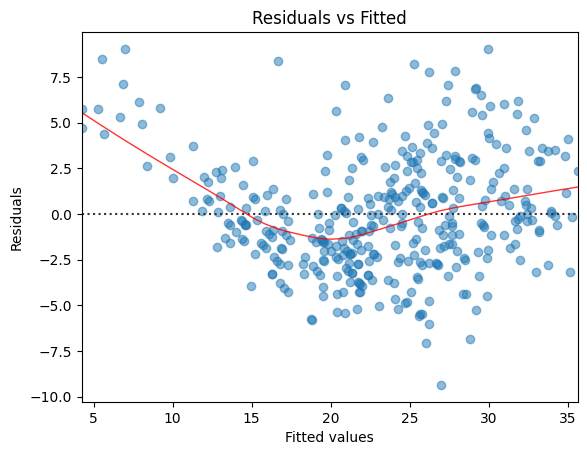

In [ ]:
# I residui sono sparsi in modo più aleatorio rispetto a prima, ciò comporta un sensibile miglioramento rispetto al modello precedente.

plot = sns.residplot(x=model_fitted_cook_r_y, y='mpg', data=df_clean_cook, lowess=True,
                     scatter_kws={'alpha': 0.5},line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plot.set_title('Residuals vs Fitted')
plot.set_xlabel('Fitted values')
plot.set_ylabel('Residuals');
plt.show()

## 5) Regressione lineare con variabile alterata

In [ ]:
# Aggiungendo la variabile horspower**2 si ha un modello decisamente migliore con R square e Adjusted superiori, 0.86%.
# La regressione continua ad essere fortemente significativa con una P value pressoché nulla.
# Gli indici AIC e BIC, di valore 1782 e 1810 contro i precedenti 1910 e 1933, confermano questa evoluzione.
# Sia P Omnibus  che  P(JB) hanno un valore inferiore a 0.05. Il primo parametro è addirittura nullo, confermando un rigetto dell'ipotesi di distribuzione gaussiana dei residui.
# Tenuto conto dello Skew, 0.430, la distribuzione dei residui risulta leggermente meno simmetrica rispetto all'antecedente modello con sempre un'accentuato peso sulla coda positiva.
# La Kurtosis riconferma la mancata normalità con un valore superiore alla soglia, 3.

model_cook2 = smf.ols("mpg ~    I(horsepower**2) + horsepower + acceleration + year + origin_Europa + origin_Giappone", data=df_clean_cook)
regr_cook2 = model_cook2.fit()
summary_cook2 = regr_cook2.summary()
print(summary_cook2)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     384.0
Date:                Tue, 16 Sep 2025   Prob (F-statistic):          1.39e-153
Time:                        18:23:22   Log-Likelihood:                -884.11
No. Observations:                 369   AIC:                             1782.
Df Residuals:                     362   BIC:                             1810.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             15.9640      4

Text(0.5, 1.0, 'Histogram of Residuals')

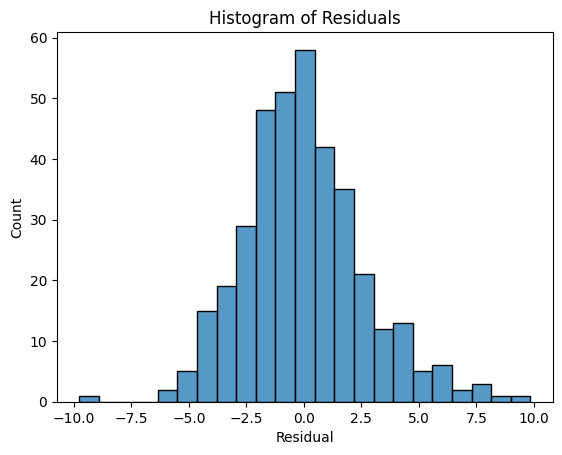

In [ ]:
# Sia il seguente istogramma che il successivo Q-Q plot validano la nostra interpretazione di una diffusione pseudo-normale con una notabile asimmetria verso i valori positivi, a destra.


model_fitted_cook2 = regr_cook2.fittedvalues
resid_cook2 = regr_cook2.resid

fig = sns.histplot(data = resid_cook2)
fig.set_xlabel('Residual')
fig.set_title('Histogram of Residuals')

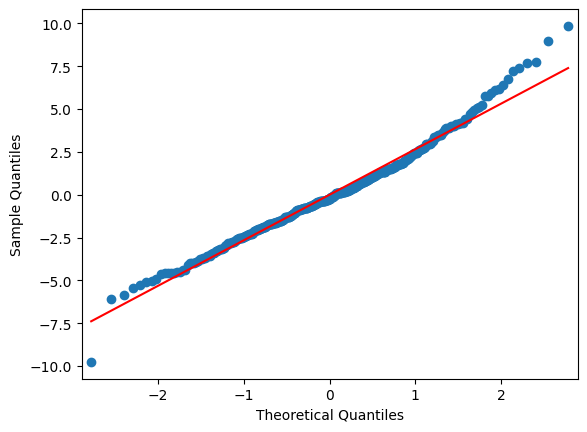

In [ ]:
fig2=sm.qqplot(data = resid_cook2, line = 's')
plt.show()

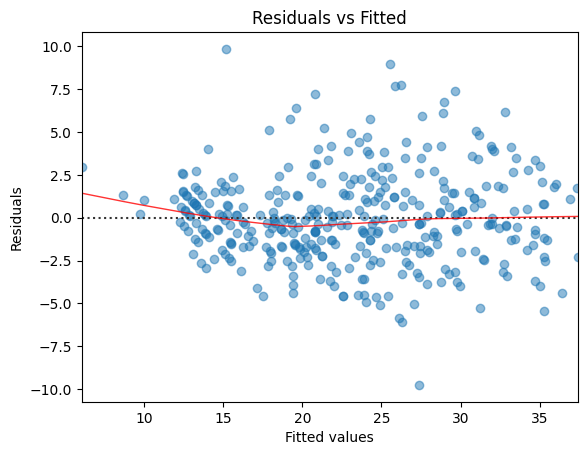

In [ ]:
# La modifica degli imput ha portato ad una correzione della linearità del modello. La LOWESS, che prima si presentava incurvata a causa del peso dei valori estremi su di essa,
# Adesso è seniibilmente più orizzontale aviccinandosi allo zero fino ad annullarsi.
# La ripartizione dei punti assume una forma più nebulosa rispetto alla distribuzione vista precedentemente.
# Ciò, unita alla trasformazione in positivo della LOWESS, segnala un'ottimizzizazione nel grado di omoschedasticità.


plot = sns.residplot(x=model_fitted_cook2, y='mpg', data=df_clean_cook, lowess=True,
                     scatter_kws={'alpha': 0.5},line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plot.set_title('Residuals vs Fitted')
plot.set_xlabel('Fitted values')
plot.set_ylabel('Residuals');
plt.show()